In [19]:
%load_ext autoreload
%autoreload 2

import torch
import matplotlib.pyplot as plt

from retarget.model import TransformerAutoEncoder
from retarget.tokenizer import Tokenizer
from retarget.utils.BVH import load
from retarget.utils.visualize import plot_pose

# initlize model and tokenizer
model = TransformerAutoEncoder.from_pretrained('local/best_model')
tokenizer = Tokenizer()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
cache_path ./models/local/best_model.pt
Using cached model


## Loading Data

In [25]:
# load an example animation
animation, _, _ = load('./data/Combined/test/bandai-namco/dataset-1_bow_active_001.bvh')

# display the number of frames
len(animation)

128

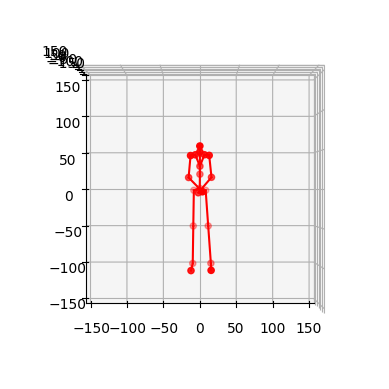

In [26]:
# plot an example frame
ax = plt.axes(projection='3d')
plot_pose(animation.positions[28], animation.edges, c='r', ax=ax)
ax.set_xlim(-150, 150)
ax.set_ylim(-150, 150)
ax.set_zlim(-150, 150)
plt.show()

## Reconstructing the animation using the model

In [34]:
# convert the animation to a graph
data = animation.as_graph()

# encode the graph using the tokenizer
batch, mask = tokenizer.encode(data)

In [28]:
# run the model
with torch.inference_mode():
    # encode the animation into the latent space
    latent, logvar = model.encoder(batch.x, batch.pos, batch.edge_index, mask=mask)

    print(latent.shape)

    # decode the latent space back into the animation
    y_pred = model.decoder(latent, batch.pos, batch.edge_index, mask=mask)

# decode the animation
fk_pose, edge_indexs = tokenizer.decode(batch, y_pred)

torch.Size([128, 64])


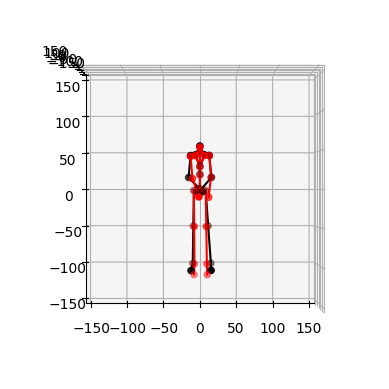

In [33]:
# plot the reconstructed frame with the original frame, black is the original, red is the reconstructed

ax = plt.axes(projection='3d')

plot_pose(animation.positions[28], animation.edges, c='k', ax=ax)
plot_pose(fk_pose[28].detach().numpy(), edge_indexs[28], c='r', ax=ax)

ax.set_xlim(-150, 150)
ax.set_ylim(-150, 150)
ax.set_zlim(-150, 150)
plt.show()